### 상관분석
- 칼럼명 -> 변수 예) 수학점수, 용돈, 공부시간
- 산점도, 히트맵 등

#### 1. 데이터 불러오기

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 아래 코드는 한글 사용할 수 있도록 해줌
plt.rcParams["font.family"] = "Malgun Gothic"   # 한글 깨짐 방지(윈도우 기본 폰트)
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv("../data/07-1_study_habits.csv") # 상대경로
df.head()

,반,성별,공부시간,시험점수,용돈
0,C,여,2.7,63,11000
1,A,남,1.8,69,23000
2,C,남,3.5,74,27000
3,C,여,2.0,74,6000
4,A,여,3.2,64,25000


#### 2. 산점도로 관계 보기
- 보려고 하는 두 변수를 x와 y에 놓고 점을 찍어서 비교
- 공부시간, 시험점수의 관계를 비교할 수 있음

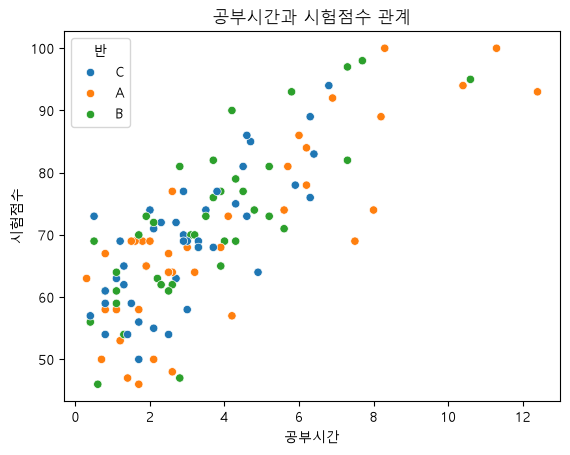

In [4]:
sns.scatterplot(data=df,
                x= "공부시간",
                y= "시험점수",
                hue="반")

plt.title("공부시간과 시험점수 관계")
plt.show()

#### 3. 상관계수
- -1 에서 1 사이의 값
- -1에 가까울수록 음의 상관관계
- 0에 가까울수록 관계 X

In [6]:
# correlation : 상관관계

corr = df["공부시간"].corr(df["시험점수"])
corr

np.float64(0.7835141064855274)

#### 4. 히트맵 - 여러 변수를 한꺼번에 보기

In [7]:
corr_matrix = df[["공부시간", "시험점수", "용돈"]].corr()
corr_matrix

,공부시간,시험점수,용돈
공부시간,1.000000,0.783514,-0.000397
시험점수,0.783514,1.000000,-0.077380
용돈,-0.000397,-0.077380,1.000000


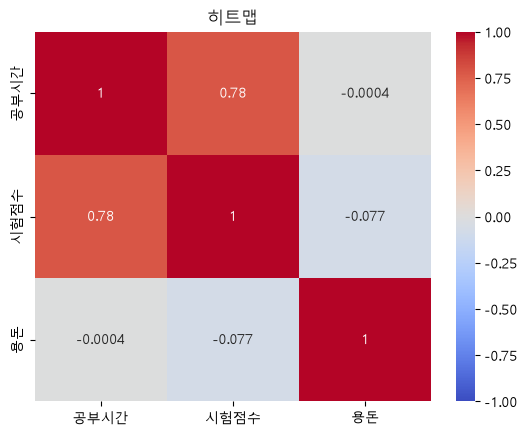

In [12]:
sns.heatmap(corr_matrix,
            annot=True,
            cmap="coolwarm",
            vmin = -1)
plt.title("히트맵")
plt.show()

- 공부시간과 시험점수는 상관계수가 0.78 -> 공부를 많이 할수록 점수가 높은 경향이 있다
- 용돈은 다른 변수와 상관관계가 거의 없다
- 상관계수가 높다고 무조건 인과관계가 되지는 않는다
 -> 실제 원인을 볼 필요 있음
 - 상관계수가 0이다 -> 두 변수 반드시 관계가 없지만은 않다. 직선관계 아닐 수 있으니 그래프 모양 잘 확인해야